# Predictive Analytics: Support Vector Machine (SVM)

This notebook implements a complete machine learning pipeline using **Support Vector Regression (SVR)** to predict taxi trip demand in Chicago under various spatio-temporal resolutions.

In [8]:
import warnings
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.svm import SVR, LinearSVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
)
import geopandas as gpd
import contextily as ctx
import shapely

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the temporal data splits

In [9]:
## Import the data-splits:
df_train = pd.read_parquet("../data/prediction_split/df_train.parquet")
df_val = pd.read_parquet("../data/prediction_split/df_val.parquet")
df_test = pd.read_parquet("../data/prediction_split/df_test.parquet")
print(f"Train split loaded. Shape: {df_train.shape}")
print(f"Validation split loaded. Shape: {df_val.shape}")
print(f"Test split loaded. Shape: {df_test.shape}")

TARGET = "Total_Trip_Start" # Target variable for prediction
zero_frac = (df_train[TARGET] == 0).mean()
print(f"\nTarget '{TARGET}': mean={df_train[TARGET].mean():.3f}, "
      f"median={df_train[TARGET].median():.0f}, max={df_train[TARGET].max():.0f}, "
      f"zeros={zero_frac:.1%}")

Train split loaded. Shape: (4641696, 37)
Validation split loaded. Shape: (1852320, 37)
Test split loaded. Shape: (2778934, 37)

Target 'Total_Trip_Start': mean=0.585, median=0, max=328, zeros=97.1%


In [10]:
# Derive cell-centroid lat/lon from the H3 index for every split.
# The original PickupLatitude/Longitude were per-hour *trip* averages and are
# undefined for the 97% of zero-demand hours, so they can't locate empty hexagons.
# h3.cell_to_latlng() gives a stable centroid for every cell regardless of demand.
def add_cell_centroids(df):
    latlng = df["h3_index"].map(h3.cell_to_latlng)
    df["lat"] = latlng.map(lambda x: x[0])
    df["lon"] = latlng.map(lambda x: x[1])
    return df

for _df in (df_train, df_val, df_test):
    add_cell_centroids(_df)

print("Added lat/lon centroids. Train lat range:",
      f"[{df_train['lat'].min():.4f}, {df_train['lat'].max():.4f}], "
      f"lon range: [{df_train['lon'].min():.4f}, {df_train['lon'].max():.4f}]")

Added lat/lon centroids. Train lat range: [41.6501, 42.0198], lon range: [-87.9049, -87.5291]


**The target is 97% zeros:** a uniform 10k subsample sees almost no demand, so the model would just predict ≈0 everywhere.

## 2. Feature Selection

# TODO: **Cell-centroid `lat` / `lon`** — recomputed from the H3 index so every hexagon is
  uniquely locatable (the original `PickupLatitude/Longitude` were per-hour *trip*
  averages, undefined for the 97% of zero-demand hours).

In [11]:
df_train.columns

Index(['hour', 'h3_index', 'Total_Trip_Start', 'Unique Taxis',
       'AvgTripSeconds', 'AvgTripMiles', 'AvgFare', 'MostCommonCompany',
       'CompanyCount', 'PickupLatitude', 'PickupLongitude', 'Total_Trip_End',
       'scikit_distance_to_loop', 'month', 'day_of_week', 'hour_of_day',
       'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'is_holiday', 'poi_cat_automotive', 'poi_cat_civic_community',
       'poi_cat_education', 'poi_cat_entertainment', 'poi_cat_finance',
       'poi_cat_food_drink', 'poi_cat_grocery', 'poi_cat_health',
       'poi_cat_leisure_sports', 'poi_cat_lodging', 'poi_cat_nightlife',
       'poi_cat_services', 'poi_cat_shopping', 'poi_cat_transport',
       'base_demand', 'lat', 'lon'],
      dtype='str')

In [12]:
# Select final features
POI_COLS = [c for c in df_train.columns if c.startswith("poi_cat_")]
features = (
    ["hour_sin", "hour_cos", "month_sin", "month_cos",
     "is_weekend", "is_holiday", "day_of_week",
     "lat", "lon", "scikit_distance_to_loop", "base_demand"]
    + POI_COLS
    # TODO: Add weather features
    # TODO: Add more spatial features like distance to CBD, distance to nearest transit stop, etc.
)

print(f"{len(features)} features ({len(POI_COLS)} POI categories):")
print(list(features))

25 features (14 POI categories):
['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_holiday', 'day_of_week', 'lat', 'lon', 'scikit_distance_to_loop', 'base_demand', 'poi_cat_automotive', 'poi_cat_civic_community', 'poi_cat_education', 'poi_cat_entertainment', 'poi_cat_finance', 'poi_cat_food_drink', 'poi_cat_grocery', 'poi_cat_health', 'poi_cat_leisure_sports', 'poi_cat_lodging', 'poi_cat_nightlife', 'poi_cat_services', 'poi_cat_shopping', 'poi_cat_transport']


In [13]:
# Scaling
scaler = StandardScaler().fit(df_train[features])

# Transform features and target for train, val, test sets
X_train = scaler.transform(df_train[features])
y_train = df_train[TARGET].values

X_val = scaler.transform(df_val[features])
y_val = df_val[TARGET].values

X_test = scaler.transform(df_test[features])
y_test = df_test[TARGET].values

# log1p target (train on this, invert before scoring)
yt_train = np.log1p(y_train)

def to_counts(pred_log):
    """Invert log1p and clip negative demand to 0."""
    return np.clip(np.expm1(pred_log), 0, None)

def score(y_true, pred_counts, name):
    mae = mean_absolute_error(y_true, pred_counts)
    rmse = np.sqrt(mean_squared_error(y_true, pred_counts))
    r2 = r2_score(y_true, pred_counts)
    print(f"{name:28s} MAE={mae:6.3f}  RMSE={rmse:6.3f}  R2={r2:7.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

## 3. Class-balanced sampling

When sampling *uniformly*, we draw ~97% zeros. Instead we draw a **balanced** sample, all non-zero rows plus an equal number of zeros, so the regressor actually sees demand.

In [14]:
def balanced_sample(df, n_per_class=12000, seed=RANDOM_STATE):
    nz = df[df[TARGET] > 0]
    z = df[df[TARGET] == 0]
    nz_s = nz.sample(n=min(n_per_class, len(nz)), random_state=seed)
    z_s = z.sample(n=min(n_per_class, len(z)), random_state=seed)
    return pd.concat([nz_s, z_s]).sample(frac=1, random_state=seed)

sample = balanced_sample(df_train)
Xs = scaler.transform(sample[features])
ys = np.log1p(sample[TARGET].values)
print(f"Balanced training sample: {len(sample)} rows with"
      f"{(sample[TARGET] > 0).mean():.0%} non-zero (vs {(df_train[TARGET] > 0).mean():.1%} in full train)")

Balanced training sample: 24000 rows with50% non-zero (vs 2.9% in full train)


## 4. Kernel comparison — selected on the **validation** split
Train SVR models starting with a Linear kernel and progressively introduce Polynomial and RBF kernels.

In [15]:
KERNELS = ["linear", "poly", "rbf"]
val_r2 = {}

for kernel in KERNELS:
    print(f"Training SVR with {kernel} kernel...")
    svr = SVR(kernel=kernel, C=1.0, gamma="scale", cache_size=500)
    svr.fit(Xs, ys) # Fit on balanced sample to speed up training (SVR scales poorly with large datasets)
    y_pred = to_counts(svr.predict(X_val))
    val_r2[kernel] = r2_score(y_val, y_pred)
    print(f"SVR({kernel:6s}) validation R2 = {val_r2[kernel]:.4f}")

best_kernel = max(val_r2, key=val_r2.get)
print(f"\nBest kernel on validation: {best_kernel}")

Training SVR with linear kernel...
SVR(linear) validation R2 = -66.5083
Training SVR with poly kernel...
SVR(poly  ) validation R2 = 0.8515
Training SVR with rbf kernel...
SVR(rbf   ) validation R2 = 0.8715

Best kernel on validation: rbf


## 5. Hyperparameter Grid Search (CV on the training sample)
Optimize the `C` and `gamma` hyperparameters for best kernel via grid search.

In [16]:
param_grid = {
    "C": [1, 10, 50],
    "gamma": ["scale", 0.05, 0.2],
}
if best_kernel == "poly":
    param_grid["degree"] = [2, 3]

grid = GridSearchCV(
    SVR(kernel=best_kernel, cache_size=500),
    param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid.fit(Xs, ys)
print("Best params:", grid.best_params_)

# Validate the tuned model on df_val
tuned = grid.best_estimator_
val_pred = to_counts(tuned.predict(X_val))
print(f"Tuned SVR({best_kernel}) validation R2 = {r2_score(y_val, val_pred):.4f}")

Best params: {'C': 50, 'gamma': 'scale'}
Tuned SVR(rbf) validation R2 = 0.8886


## 6. Final evaluation on the **test** split

In [17]:
# TODO: Compare with Deep Learning model

results = []
results.append(score(y_test, to_counts(tuned.predict(X_test)), f"Tuned SVR ({best_kernel})"))
# y_pred_two = two_stage_predict(X_test)
# results.append(score(y_test, y_pred_two, "Two-stage (gate + SVR)"))

df_metrics = pd.DataFrame(results)
print("\nModel Performance Comparison on the Test set)")
print(df_metrics.to_string(index=False))

# Pick the best model by test R2 for the spatial analysis below
best_row = df_metrics.loc[df_metrics["R2"].idxmax(), "Model"]
y_pred_best = {
    f"Tuned SVR ({best_kernel})": to_counts(tuned.predict(X_test)),
    #"Two-stage (gate + SVR)": y_pred_two,
}[best_row]
print(f"\nBest model for spatial analysis: {best_row}")

Tuned SVR (rbf)              MAE= 0.345  RMSE= 2.500  R2= 0.8628

Model Performance Comparison on the Test set)
          Model     MAE     RMSE       R2
Tuned SVR (rbf) 0.34492 2.499658 0.862767

Best model for spatial analysis: Tuned SVR (rbf)


## 6b. Persist the best model

Save the tuned SVR to `../models/` so it can be reused without retraining. We store the
estimator together with everything needed for inference — the fitted `scaler`, the
`features` list, the target name, and the `log1p`/clip post-processing — plus the test
metrics for provenance.

In [18]:
import joblib

MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Bundle the estimator with everything needed to make predictions later.
best_metrics = df_metrics.loc[df_metrics["R2"].idxmax()].to_dict()
model_bundle = {
    "model": tuned,                 # fitted SVR (best_estimator_ from grid search)
    "scaler": scaler,               # fitted StandardScaler
    "features": features,           # feature column order expected by the scaler
    "target": TARGET,
    "kernel": best_kernel,
    "best_params": grid.best_params_,
    "transform": "log1p",           # target was trained on log1p(y); invert with expm1 + clip>=0
    "metrics": best_metrics,
}

model_path = MODELS_DIR / "svr_best.joblib"
joblib.dump(model_bundle, model_path)
print(f"Saved best model -> {model_path.resolve()}")
print(f"  kernel={best_kernel}, params={grid.best_params_}")
print(f"  test metrics: MAE={best_metrics['MAE']:.3f}  "
      f"RMSE={best_metrics['RMSE']:.3f}  R2={best_metrics['R2']:.4f}")

# Sanity check: reload and reproduce a prediction.
_b = joblib.load(model_path)
_pred = np.clip(np.expm1(_b["model"].predict(_b["scaler"].transform(df_test[_b["features"]].head()))), 0, None)
print("Reloaded model OK; sample predictions:", np.round(_pred, 3))

Saved best model -> /Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/models/svr_best.joblib
  kernel=rbf, params={'C': 50, 'gamma': 'scale'}
  test metrics: MAE=0.345  RMSE=2.500  R2=0.8628
Reloaded model OK; sample predictions: [ 0.589 17.197  0.838  0.504  1.828]


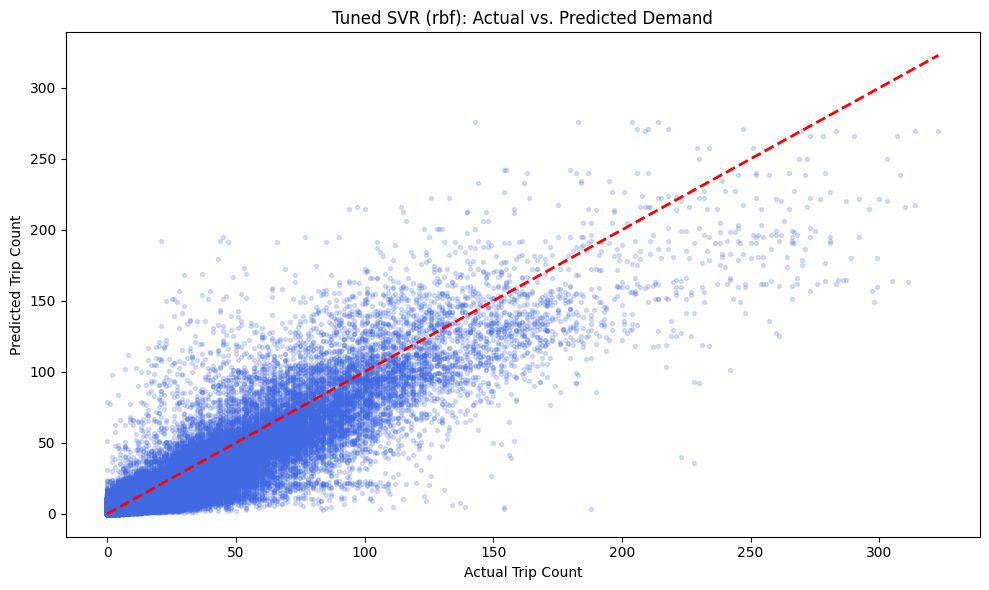

In [19]:
#| label: fig-svm-pred-vs-actual
# Predicted vs actual for the best model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.2, s=8, color="royalblue")
lim = y_test.max()
plt.plot([0, lim], [0, lim], "r--", lw=2)
plt.title(f"{best_row}: Actual vs. Predicted Demand")
plt.xlabel("Actual Trip Count")
plt.ylabel("Predicted Trip Count")
plt.tight_layout()
plt.show()

## 9. Spatial prediction quality
The aggregate metrics above collapse the whole city into a single number and hide strong **spatial** variation in how well the model performs. Here we visualize the SVR predictions on the test set and aggregate the error by H3 cell. 
Two complementary views answer "where does the model work?":

- **MAE per hexagon** — the absolute size of the prediction miss (trips/hour).
- **R² per hexagon** — how much of each cell's hour-to-hour demand *variation* the
  model explains. Cells whose demand is essentially flat (the quiet outskirts)
  have no variation to explain, so their R² is undefined and they are greyed out.

In [20]:
# Community area outlines, used as a spatial reference overlay in the choropleths.
community_areas = gpd.read_file(Path("..") / "data" / "chicago_community_areas.gpkg")

def get_hexagon_grid(data, h3_col="h3_index"):
    """
    Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source.
    """
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        h3_list = list(data)
        df = pd.DataFrame({"h3_index": h3_list})
    else:
        h3_list = list(data[h3_col])
        df = data.reset_index(drop=True)
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def create_choropleth_plot(gdf, value_col="poi_count", title="", boundaries=None,
                           cmap="YlOrRd", figsize=(6, 8), k=7):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.
    """
    if boundaries is None:
        boundaries = community_areas
    fig, ax = plt.subplots(figsize=figsize)
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap, scheme="quantiles", k=k,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    boundaries.to_crs(epsg=3857).boundary.plot(
        ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()
    return fig, ax

In [21]:
#| label: tbl-svm-hex-performance
# Per-hexagon performance for the best model
df_eval = df_test[["h3_index", TARGET]].copy()
df_eval["y_pred"] = y_pred_best
df_eval["abs_err"] = (df_eval[TARGET] - df_eval["y_pred"]).abs()
df_eval["sq_err"] = (df_eval[TARGET] - df_eval["y_pred"]) ** 2

grp = df_eval.groupby("h3_index")
hex_perf = grp.agg(
    n_obs=(TARGET, "size"),
    mean_actual=(TARGET, "mean"),
    var_actual=(TARGET, "var"),
    mae=("abs_err", "mean"),
    mse=("sq_err", "mean"),
)
hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
ss_res = grp["sq_err"].sum()
ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col="h3_index")

busy = hex_perf[hex_perf["mean_actual"] > 1]
n_bad = (busy["r2"] < -0.3).sum()
print(f"{len(hex_perf)} hexagons evaluated; "
      f"{hex_perf['r2'].notna().sum()} have enough variation for an R2.")
print(f"Busy cells (mean>1) with R2 < -0.3: {n_bad}  (original model had several)")
print("\nWorst-predicted busy cells (lowest R2):")
print(busy.nsmallest(5, "r2")[["h3_index", "n_obs", "mean_actual", "mae", "rmse", "r2"]]
      .to_string(index=False))

454 hexagons evaluated; 276 have enough variation for an R2.
Busy cells (mean>1) with R2 < -0.3: 0  (original model had several)

Worst-predicted busy cells (lowest R2):
       h3_index  n_obs  mean_actual      mae     rmse        r2
882664c1a3fffff   6121     2.818167 2.473231 4.161451 -0.013528
882664cad7fffff   6121     4.696291 3.748813 6.103780  0.097719
882664ca99fffff   6121     1.426564 1.569007 2.584696  0.139603
882664c1e5fffff   6121     7.878124 5.129729 7.923475  0.180417
882664c1a7fffff   6121     1.026956 0.963963 1.747448  0.213296


### Map 1: mean absolute error (MAE) per hexagon
This is the absolute size of the prediction miss. Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop; the quiet outskirts have tiny MAE simply because there is little demand.

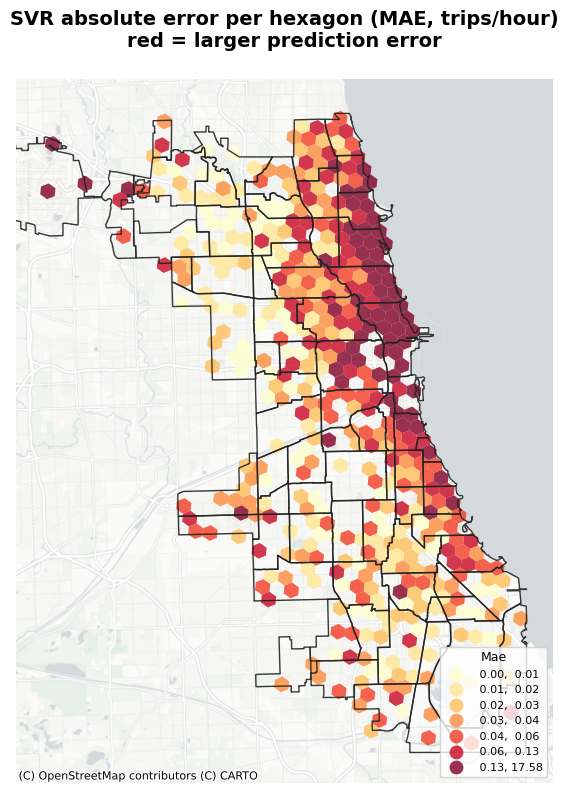

In [23]:
#| label: fig-svm-hex-mae
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='mae',
    title='SVR absolute error per hexagon (MAE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

### Map 2: mean relative error (MRE) per hexagon
This is the relative size of the prediction miss. 

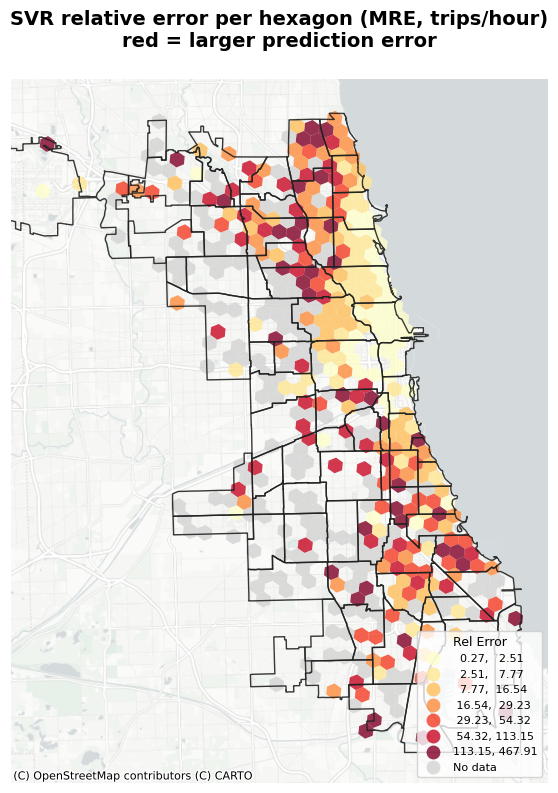

In [24]:
#| label: fig-svm-hex-mre
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='rel_error',
    title='SVR relative error per hexagon (MRE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

### Map 3: coefficient of determination (R2) per hexagon.
R2 measures how much of each cell's hour-to-hour demand *variation* the model explains. Cells whose demand never moves (flat ~0 in the outskirts) have no variance to explain -> R2 is undefined and they are drawn grey ("No data"). Green = the temporal demand pattern is captured well; red = poorly.

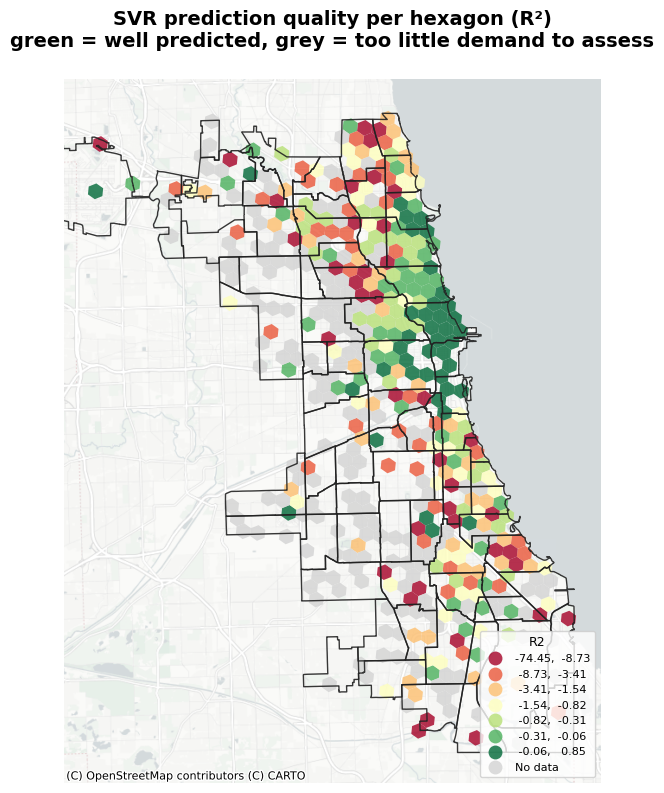

In [25]:
#| label: fig-svm-hex-r2
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='r2',
    title='SVR prediction quality per hexagon (R²)\ngreen = well predicted, grey = too little demand to assess',
    cmap='RdYlGn',
    k=7,
)
plt.show()

In [26]:
# TODO: Add Temporal Resolution Analysis
# TODO: Spatial Resolution with Census Tracts
# TODO: Answering the "Outskirts Rainy Sunday" Scenario
# TODO: Add Feature Importance Analysis (SHAP or similar)
# TODO: To push further: a coarser H3 resolution (fewer all-zero cells), or quantile/Tweedie losses, would suit the zero-inflated target.


## 7. Two-stage model (gate + regressor)

#Because 97% of hex-hours are zero, a natural formulation is: first **classify** whether a
#cell is active in a given hour, then **regress** demand only where it is. Both stages use
#SVMs, keeping this firmly in the "SVM" section.

"""

# Stage 1: SVC active-vs-zero gate (trained on the balanced sample)
gate = SVC(kernel="rbf", C=1.0, gamma="scale", cache_size=500, random_state=RANDOM_STATE)
gate.fit(Xs, (sample[TARGET].values > 0).astype(int))

# Stage 2: SVR trained ONLY on active rows (log1p demand)
active = df_train[df_train[TARGET] > 0]
active_s = active.sample(n=min(20000, len(active)), random_state=RANDOM_STATE)
Xa = scaler.transform(active_s[features])
ya = np.log1p(active_s[TARGET].values)
reg = SVR(kernel=best_kernel, **grid.best_params_, cache_size=500)
reg.fit(Xa, ya)

def two_stage_predict(X):
    is_active = gate.predict(X)
    demand = to_counts(reg.predict(X))
    return demand * is_active

print(f"Two-stage validation R2 = {r2_score(y_val, two_stage_predict(X_val)):.4f}")
"""

'\n\n# Stage 1: SVC active-vs-zero gate (trained on the balanced sample)\ngate = SVC(kernel="rbf", C=1.0, gamma="scale", cache_size=500, random_state=RANDOM_STATE)\ngate.fit(Xs, (sample[TARGET].values > 0).astype(int))\n\n# Stage 2: SVR trained ONLY on active rows (log1p demand)\nactive = df_train[df_train[TARGET] > 0]\nactive_s = active.sample(n=min(20000, len(active)), random_state=RANDOM_STATE)\nXa = scaler.transform(active_s[features])\nya = np.log1p(active_s[TARGET].values)\nreg = SVR(kernel=best_kernel, **grid.best_params_, cache_size=500)\nreg.fit(Xa, ya)\n\ndef two_stage_predict(X):\n    is_active = gate.predict(X)\n    demand = to_counts(reg.predict(X))\n    return demand * is_active\n\nprint(f"Two-stage validation R2 = {r2_score(y_val, two_stage_predict(X_val)):.4f}")\n'